In [1]:
import geopandas as gpd
import numpy as np

/opt/anaconda3/envs/spatial_data_science/lib/python3.8/site-packages/geopandas/_compat.py:124: UserWarning: The Shapely GEOS version (3.9.1dev-CAPI-1.14.1) is incompatible with the GEOS version PyGEOS was compiled with (3.9.1-CAPI-1.14.2). Conversions between both will be slow.
  warnings.warn(
/var/folders/1q/gmt0p2p959x208n6_4vlpmc80000gn/T/ipykernel_11095/443725808.py:1: DeprecationWarning: Shapely 2.0 is installed, but because PyGEOS is also installed, GeoPandas still uses PyGEOS by default. However, starting with version 0.14, the default will switch to Shapely. To force to use Shapely 2.0 now, you can either uninstall PyGEOS or set the environment variable USE_PYGEOS=0. You can do this before starting the Python process, or in your code before importing geopandas:

import os
os.environ['USE_PYGEOS'] = '0'
import geopandas

In the next release, GeoPandas will switch to using Shapely by default, even if PyGEOS is installed. If you only have PyGEOS installed to get speed-ups, this s

In [2]:
import requests
import pandas as pd
from pandas import json_normalize
from openaq import OpenAQ
import openaq
import pprint
import json
import datetime
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [3]:
client = OpenAQ(api_key="cac2ad4059ea1024420972a68e686536f34676e3ebd88be8beef18b653686ba5")

In [4]:
loc = client.locations.list(
    iso="GH",
    limit=1000,
    parameters_id=2
)

In [5]:
loc_df = json_normalize(loc.dict()["results"])
location_ids = loc_df["id"].tolist()

In [6]:
sensor_rows = []

for _, row in loc_df.iterrows():
    sensors = row.get("sensors", None)
    if isinstance(sensors, list):
        for s in sensors:
            s["location_id"] = row["id"]
            sensor_rows.append(s)

sdf = pd.DataFrame(sensor_rows)

In [7]:
sdf = sdf.rename(columns={"id": "sensor_id"})

# Keep only useful columns
sdf = sdf[["sensor_id", "location_id", "parameter"]]

In [8]:
pm25_sensors = sdf[sdf["parameter"].apply(lambda x: isinstance(x, dict) and x["name"] == "pm25")]

pm25_sensor_ids = pm25_sensors["sensor_id"].tolist()

print("Number of PM2.5 sensors:", len(pm25_sensor_ids))
print("Sensor IDs:", pm25_sensor_ids[:10])

Number of PM2.5 sensors: 82
Sensor IDs: [5, 8, 9, 12, 13, 15, 18, 19, 21, 30469]


In [9]:
all_pm25 = []

for sid in pm25_sensor_ids:
    try:
        resp = client.measurements.list(
            sensors_id=sid,
            limit=1000,
            datetime_from="2025-01-01",
            datetime_to='2026-03-31'
        )
        data = resp.dict()

        if "results" in data and data["results"]:
            df_m = json_normalize(data["results"])
            df_m["sensor_id"] = sid
            all_pm25.append(df_m)
        else:
            print(f"No PM2.5 data for sensor {sid}")

    except Exception as e:
        print(f"Error fetching sensor {sid}: {e}")

client.close()

No PM2.5 data for sensor 5
No PM2.5 data for sensor 8
No PM2.5 data for sensor 9
No PM2.5 data for sensor 12
No PM2.5 data for sensor 13
No PM2.5 data for sensor 15
No PM2.5 data for sensor 18
No PM2.5 data for sensor 19
No PM2.5 data for sensor 21
No PM2.5 data for sensor 2087968
No PM2.5 data for sensor 2087833
No PM2.5 data for sensor 2087837
No PM2.5 data for sensor 2087893
No PM2.5 data for sensor 2087831
No PM2.5 data for sensor 6673395
No PM2.5 data for sensor 6809828
No PM2.5 data for sensor 15872035
No PM2.5 data for sensor 15872036
No PM2.5 data for sensor 15872033
No PM2.5 data for sensor 15872034
No PM2.5 data for sensor 15905125
No PM2.5 data for sensor 15905128
No PM2.5 data for sensor 15905130
No PM2.5 data for sensor 15905127
No PM2.5 data for sensor 15905124
No PM2.5 data for sensor 15905129
No PM2.5 data for sensor 15905126
No PM2.5 data for sensor 15905131
No PM2.5 data for sensor 15913720
No PM2.5 data for sensor 15913719
No PM2.5 data for sensor 15913721
No PM2.5 d

In [10]:
pm25_df = pd.concat(all_pm25, ignore_index=True)

# Keep only essential columns
pm25_df = pm25_df[[
    "sensor_id",
    "value",
    "period.datetime_from.utc",
    "period.datetime_from.local"
]]

In [11]:
# Merge PM data with sensor info
merged = pm25_df.merge(pm25_sensors, on="sensor_id", how="left")

In [12]:
final_df = merged.merge(loc_df, left_on="location_id", right_on="id", how="left")

In [13]:
final_df.head()

,sensor_id,value,period.datetime_from.utc,period.datetime_from.local,location_id,parameter,id,name,locality,timezone,...,owner.id,owner.name,provider.id,provider.name,coordinates.latitude,coordinates.longitude,datetime_first.utc,datetime_first.local,datetime_last.utc,datetime_last.local
0,30469,-999.0,2025-01-01T00:00:00Z,2025-01-01T00:00:00Z,9764,"{'id': 2, 'name': 'pm25', 'units': 'µg/m³', 'd...",9764,US Diplomatic Post: Accra,Accra,Africa/Accra,...,4,Unknown Governmental Organization,234,StateAir Accra,5.579447,-0.170699,2020-05-01T01:00:00Z,2020-05-01T01:00:00Z,2025-03-04T12:00:00Z,2025-03-04T12:00:00Z
1,30469,-999.0,2025-01-01T01:00:00Z,2025-01-01T01:00:00Z,9764,"{'id': 2, 'name': 'pm25', 'units': 'µg/m³', 'd...",9764,US Diplomatic Post: Accra,Accra,Africa/Accra,...,4,Unknown Governmental Organization,234,StateAir Accra,5.579447,-0.170699,2020-05-01T01:00:00Z,2020-05-01T01:00:00Z,2025-03-04T12:00:00Z,2025-03-04T12:00:00Z
2,30469,-999.0,2025-01-01T02:00:00Z,2025-01-01T02:00:00Z,9764,"{'id': 2, 'name': 'pm25', 'units': 'µg/m³', 'd...",9764,US Diplomatic Post: Accra,Accra,Africa/Accra,...,4,Unknown Governmental Organization,234,StateAir Accra,5.579447,-0.170699,2020-05-01T01:00:00Z,2020-05-01T01:00:00Z,2025-03-04T12:00:00Z,2025-03-04T12:00:00Z
3,30469,-999.0,2025-01-01T03:00:00Z,2025-01-01T03:00:00Z,9764,"{'id': 2, 'name': 'pm25', 'units': 'µg/m³', 'd...",9764,US Diplomatic Post: Accra,Accra,Africa/Accra,...,4,Unknown Governmental Organization,234,StateAir Accra,5.579447,-0.170699,2020-05-01T01:00:00Z,2020-05-01T01:00:00Z,2025-03-04T12:00:00Z,2025-03-04T12:00:00Z
4,30469,-999.0,2025-01-01T04:00:00Z,2025-01-01T04:00:00Z,9764,"{'id': 2, 'name': 'pm25', 'units': 'µg/m³', 'd...",9764,US Diplomatic Post: Accra,Accra,Africa/Accra,...,4,Unknown Governmental Organization,234,StateAir Accra,5.579447,-0.170699,2020-05-01T01:00:00Z,2020-05-01T01:00:00Z,2025-03-04T12:00:00Z,2025-03-04T12:00:00Z


In [14]:
geo = final_df[['sensor_id', 'name','value',
       'period.datetime_from.local', 'location_id', 'name','coordinates.latitude',
       'coordinates.longitude',]]

In [15]:
geo = geo.rename(columns={
    "name_x": "station_name",
    "name_y": "sensor_name"
})

In [16]:
geo.columns = [
    "sensor_id",
    "sensor_name",
    "value",
    "datetime",
    "location_id",
    "location_name",
    "latitude",
    "longitude"
]

In [17]:
geo.groupby("location_name")

In [18]:
geo1 = geo.copy()

In [19]:
geo1["datetime"] = pd.to_datetime(geo1["datetime"])

In [20]:
gdf = gpd.GeoDataFrame(
    geo1.copy(),
    geometry=gpd.points_from_xy(geo["longitude"], geo["latitude"]),
    crs="EPSG:4326"
)

In [21]:
gdf.head()

,sensor_id,sensor_name,value,datetime,location_id,location_name,latitude,longitude,geometry
0,30469,US Diplomatic Post: Accra,-999.0,2025-01-01 00:00:00+00:00,9764,US Diplomatic Post: Accra,5.579447,-0.170699,POINT (-0.17070 5.57945)
1,30469,US Diplomatic Post: Accra,-999.0,2025-01-01 01:00:00+00:00,9764,US Diplomatic Post: Accra,5.579447,-0.170699,POINT (-0.17070 5.57945)
2,30469,US Diplomatic Post: Accra,-999.0,2025-01-01 02:00:00+00:00,9764,US Diplomatic Post: Accra,5.579447,-0.170699,POINT (-0.17070 5.57945)
3,30469,US Diplomatic Post: Accra,-999.0,2025-01-01 03:00:00+00:00,9764,US Diplomatic Post: Accra,5.579447,-0.170699,POINT (-0.17070 5.57945)
4,30469,US Diplomatic Post: Accra,-999.0,2025-01-01 04:00:00+00:00,9764,US Diplomatic Post: Accra,5.579447,-0.170699,POINT (-0.17070 5.57945)


In [22]:
gdf.tail()

,sensor_id,sensor_name,value,datetime,location_id,location_name,latitude,longitude,geometry
42594,15461151,Tamale Central High Street,27.96,2026-03-06 04:23:38+00:00,6242088,Tamale Central High Street,9.40345,-0.84119,POINT (-0.84119 9.40345)
42595,15461151,Tamale Central High Street,26.81,2026-03-06 04:40:57+00:00,6242088,Tamale Central High Street,9.40345,-0.84119,POINT (-0.84119 9.40345)
42596,15461151,Tamale Central High Street,25.86,2026-03-06 04:58:18+00:00,6242088,Tamale Central High Street,9.40345,-0.84119,POINT (-0.84119 9.40345)
42597,15461151,Tamale Central High Street,21.67,2026-03-06 05:15:37+00:00,6242088,Tamale Central High Street,9.40345,-0.84119,POINT (-0.84119 9.40345)
42598,15461151,Tamale Central High Street,24.14,2026-03-06 05:32:52+00:00,6242088,Tamale Central High Street,9.40345,-0.84119,POINT (-0.84119 9.40345)


In [23]:
gh = gpd.read_file('Ga_Mantse.geojson')

In [24]:
gdf_geo = gdf.clip(gh)

In [25]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

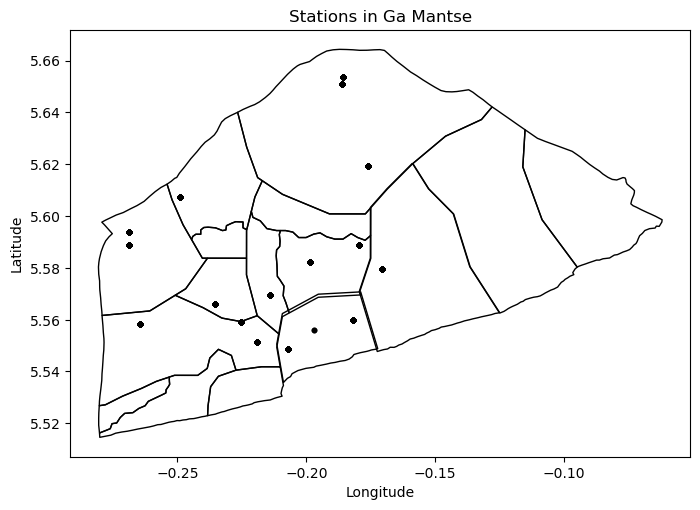

In [26]:
plt.figure(figsize=(8,6))
gh.boundary.plot(ax=plt.gca(), edgecolor='black', linewidth=1)
gdf_geo.plot(ax=plt.gca(), color='k', markersize=10)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Stations in Ga Mantse')
plt.show()

In [27]:
gdf_geo.head()

,sensor_id,sensor_name,value,datetime,location_id,location_name,latitude,longitude,geometry
14805,10330992,Makola,32.34,2025-01-15 15:31:35+00:00,3025589,Makola,5.54848,-0.2072,POINT (-0.20720 5.54848)
14804,10330992,Makola,32.96,2025-01-15 15:14:21+00:00,3025589,Makola,5.54848,-0.2072,POINT (-0.20720 5.54848)
14803,10330992,Makola,44.29,2025-01-15 14:57:08+00:00,3025589,Makola,5.54848,-0.2072,POINT (-0.20720 5.54848)
14802,10330992,Makola,33.86,2025-01-15 14:39:57+00:00,3025589,Makola,5.54848,-0.2072,POINT (-0.20720 5.54848)
14801,10330992,Makola,34.05,2025-01-15 14:22:48+00:00,3025589,Makola,5.54848,-0.2072,POINT (-0.20720 5.54848)


In [28]:
df1 = gdf_geo.copy()

In [29]:
# Replace the -999.0 flags with NaN
df1['value'] = df1['value'].replace(-999.0, np.nan)

In [30]:
# Now check how many missing values you have
print(f"Missing values: {df1['value'].isna().sum()}")

Missing values: 970


<Axes: >

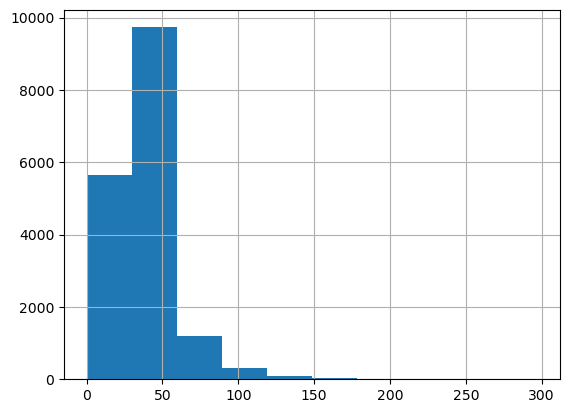

In [31]:
df1['value'].hist()

In [32]:
df1['value'] = df1['value'].fillna(df1['value'].median())

In [33]:
# Now check how many missing values you have
print(f"Missing values: {df1['value'].isna().sum()}")

Missing values: 0


In [34]:
overpass_window = df1[
    (df1['datetime'].dt.hour >= 12) & 
    (df1['datetime'].dt.hour <= 14)
].copy()

In [35]:
overpass_window.shape

(2378, 9)

In [36]:
df2 = overpass_window.copy()

In [37]:
df2.head()

,sensor_id,sensor_name,value,datetime,location_id,location_name,latitude,longitude,geometry
14803,10330992,Makola,44.29,2025-01-15 14:57:08+00:00,3025589,Makola,5.54848,-0.2072,POINT (-0.20720 5.54848)
14802,10330992,Makola,33.86,2025-01-15 14:39:57+00:00,3025589,Makola,5.54848,-0.2072,POINT (-0.20720 5.54848)
14801,10330992,Makola,34.05,2025-01-15 14:22:48+00:00,3025589,Makola,5.54848,-0.2072,POINT (-0.20720 5.54848)
14800,10330992,Makola,30.43,2025-01-15 14:05:39+00:00,3025589,Makola,5.54848,-0.2072,POINT (-0.20720 5.54848)
14799,10330992,Makola,31.66,2025-01-15 13:48:25+00:00,3025589,Makola,5.54848,-0.2072,POINT (-0.20720 5.54848)


In [38]:
df2.tail()

,sensor_id,sensor_name,value,datetime,location_id,location_name,latitude,longitude,geometry
11227,10331005,Lapaz Intersection,18.56,2025-01-01 14:44:24+00:00,3025586,Lapaz Intersection,5.60724,-0.24896,POINT (-0.24896 5.60724)
11228,10331005,Lapaz Intersection,21.97,2025-01-01 14:48:08+00:00,3025586,Lapaz Intersection,5.60724,-0.24896,POINT (-0.24896 5.60724)
11229,10331005,Lapaz Intersection,30.57,2025-01-01 14:51:49+00:00,3025586,Lapaz Intersection,5.60724,-0.24896,POINT (-0.24896 5.60724)
11230,10331005,Lapaz Intersection,22.20,2025-01-01 14:55:37+00:00,3025586,Lapaz Intersection,5.60724,-0.24896,POINT (-0.24896 5.60724)
11231,10331005,Lapaz Intersection,19.95,2025-01-01 14:59:16+00:00,3025586,Lapaz Intersection,5.60724,-0.24896,POINT (-0.24896 5.60724)


In [39]:
# 3. Aggregate to one value per station per day (The 'Satellite-View' of ground data)
df_ground_daily = df2.groupby([df2['datetime'].dt.date, 'sensor_name']).agg({
    'value': 'mean',
    'latitude': 'first',
    'longitude': 'first'
}).reset_index()

In [40]:
df_ground_daily.head()

,datetime,sensor_name,value,latitude,longitude
0,2025-01-01,37 Lorry Station,16.518222,5.588920,-0.179640
1,2025-01-01,Afri-SET,32.764902,5.653842,-0.185875
2,2025-01-01,Agbogbloshie,24.165000,5.551470,-0.219270
3,2025-01-01,Dansoman Roundabout,24.476364,5.558510,-0.264480
4,2025-01-01,Graphic Road,21.578000,5.558950,-0.225260


In [41]:
df_ground_daily.rename(columns={'datetime': 'date'}, inplace=True)
print(f"Filtered to {len(df_ground_daily)} overpass snapshots.")

Filtered to 295 overpass snapshots.


In [42]:
# 1. Create the date range for the year
all_dates = pd.date_range(start='2025-01-01', end='2025-12-31', freq='D').date

# 2. Get unique metadata from your stations
stations_meta = df_ground_daily[['sensor_name', 'latitude', 'longitude']].drop_duplicates('sensor_name')

In [43]:
# 3. Create the 7,300 row skeleton (365 days * 20 stations)
skeleton = pd.MultiIndex.from_product(
    [all_dates, stations_meta['sensor_name'].unique()],
    names=['date', 'sensor_name']
).to_frame(index=False)

In [44]:
# 1. Merge real data into skeleton
df_final = pd.merge(skeleton, df_ground_daily[['date', 'sensor_name', 'value']], 
                     on=['date', 'sensor_name'], how='left')

In [45]:
df_final.head()

,date,sensor_name,value
0,2025-01-01,37 Lorry Station,16.518222
1,2025-01-01,Afri-SET,32.764902
2,2025-01-01,Agbogbloshie,24.165000
3,2025-01-01,Dansoman Roundabout,24.476364
4,2025-01-01,Graphic Road,21.578000


In [46]:
# 2. Attach fixed coordinates to every row
df_final = pd.merge(df_final, stations_meta, on='sensor_name', how='left')

In [47]:
df_final.head()

,date,sensor_name,value,latitude,longitude
0,2025-01-01,37 Lorry Station,16.518222,5.588920,-0.179640
1,2025-01-01,Afri-SET,32.764902,5.653842,-0.185875
2,2025-01-01,Agbogbloshie,24.165000,5.551470,-0.219270
3,2025-01-01,Dansoman Roundabout,24.476364,5.558510,-0.264480
4,2025-01-01,Graphic Road,21.578000,5.558950,-0.225260


In [48]:
df_final['date'] = pd.to_datetime(df_final['date'])
df_final['day_of_year'] = df_final['date'].dt.dayofyear
df_final['is_imputed'] = df_final['value'].isna()

In [49]:
df_final.tail()

,date,sensor_name,value,latitude,longitude,day_of_year,is_imputed
6200,2025-12-31,Physics Department-UG-Accra/CAOA-UESD,NaN,5.651000,-0.186000,365,True
6201,2025-12-31,Tetteh Quarshie Interchange,NaN,5.619190,-0.176260,365,True
6202,2025-12-31,US Diplomatic Post: Accra,NaN,5.579447,-0.170699,365,True
6203,2025-12-31,MSC_2Accra25,NaN,5.556000,-0.196900,365,True
6204,2025-12-31,Tema Community Center,NaN,5.588640,-0.268670,365,True


In [50]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor

In [51]:
# 1. Separate 'Real' overpass data from 'Missing' gaps
train_set = df_final[df_final['value'].notna()].copy()
predict_set = df_final[df_final['value'].isna()].copy()

# 2. Define ML features (Space and Time)
features = ['latitude', 'longitude', 'day_of_year']

if not predict_set.empty:
    print(f"Fitting model on {len(train_set)} samples...")
    
    # 3. Initialize and Fit
    # Increased depth to capture the 'jagged' nature of Accra's air quality
    rf_model = RandomForestRegressor(n_estimators=300, max_depth=30, random_state=42)
    rf_model.fit(train_set[features], train_set['value'])
    
    # 4. Predict the gaps
    predictions = rf_model.predict(predict_set[features])
    
    # 5. Inject predictions back into the main dataframe
    df_final.loc[df_final['value'].isna(), 'value'] = predictions
    print("Full Spatio-Temporal reconstruction complete.")
else:
    print("No missing values found to fill.")

# Result: Every station now has a value for every day during the overpass window.

Fitting model on 295 samples...
Full Spatio-Temporal reconstruction complete.


In [52]:
# Sort by date and station
full_network_df = df_final.sort_values(['date', 'sensor_name']).reset_index(drop=True)

# Quick validation
print(full_network_df.head())

        date           sensor_name      value  latitude  longitude  \
0 2025-01-01     37 Lorry Station   16.518222  5.588920  -0.179640   
1 2025-01-01              Afri-SET  32.764902  5.653842  -0.185875   
2 2025-01-01         Agbogbloshie   24.165000  5.551470  -0.219270   
3 2025-01-01  Dansoman Roundabout   24.476364  5.558510  -0.264480   
4 2025-01-01          Graphic Road  21.578000  5.558950  -0.225260   

   day_of_year  is_imputed  
0            1       False  
1            1       False  
2            1       False  
3            1       False  
4            1       False  


In [53]:
full_network_df.head()

,date,sensor_name,value,latitude,longitude,day_of_year,is_imputed
0,2025-01-01,37 Lorry Station,16.518222,5.588920,-0.179640,1,False
1,2025-01-01,Afri-SET,32.764902,5.653842,-0.185875,1,False
2,2025-01-01,Agbogbloshie,24.165000,5.551470,-0.219270,1,False
3,2025-01-01,Dansoman Roundabout,24.476364,5.558510,-0.264480,1,False
4,2025-01-01,Graphic Road,21.578000,5.558950,-0.225260,1,False


In [54]:
full_network_df.tail()

,date,sensor_name,value,latitude,longitude,day_of_year,is_imputed
6200,2025-12-31,Osu Oxford Street,12.902726,5.559690,-0.182020,365,True
6201,2025-12-31,Physics Department-UG-Accra/CAOA-UESD,13.238368,5.651000,-0.186000,365,True
6202,2025-12-31,Tema Community Center,12.817230,5.588640,-0.268670,365,True
6203,2025-12-31,Tetteh Quarshie Interchange,13.022366,5.619190,-0.176260,365,True
6204,2025-12-31,US Diplomatic Post: Accra,13.044519,5.579447,-0.170699,365,True


In [131]:
full_network_df['sensor_name'].value_counts()

sensor_name
37 Lorry Station                         365
MSC_2Accra25                             365
Tetteh Quarshie Interchange              365
Tema Community Center                    365
Physics Department-UG-Accra/CAOA-UESD    365
Osu Oxford Street                        365
Nima Market                              365
Makola                                   365
Lapaz Intersection                       365
Afri-SET                                 365
Kwashieman Presby Church                 365
Kwame Nkrumah Circle                     365
Kaneshie Market                          365
Graphic Road                             365
Dansoman Roundabout                      365
Agbogbloshie                             365
US Diplomatic Post: Accra                365
Name: count, dtype: int64

In [55]:
df_grouped = full_network_df.sort_values(by=['date'])

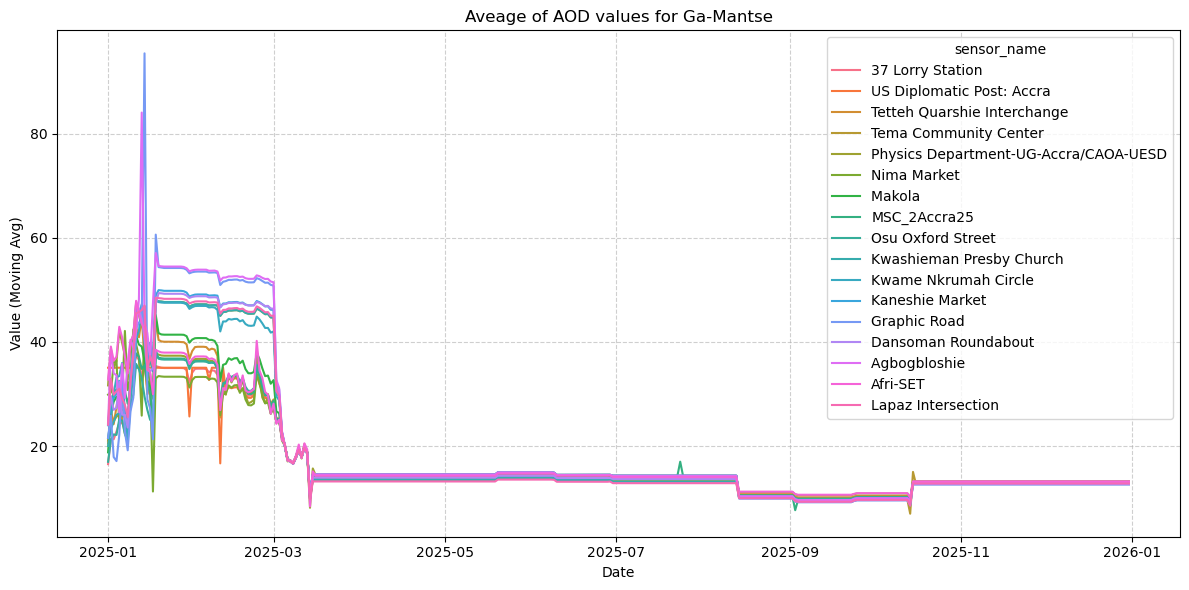

In [130]:
# 3. Plotting
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_grouped, x='date', y='value', hue = 'sensor_name')

plt.title('Aveage of AOD values for Ga-Mantse')
plt.xlabel('Date')
plt.ylabel('Value (Moving Avg)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=(10,6))

for station, df in geo.groupby("location_name"):
    df = df.set_index("datetime").sort_index()
    df["value"].plot(ax=ax, label=station)

ax.set_title("PM2.5 Time Series")
ax.set_ylabel("µg/m³")
ax.legend()
plt.show()

<Axes: >

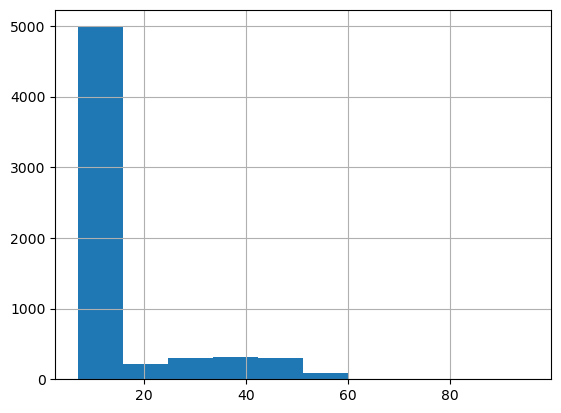

In [57]:
df_grouped['value'].hist()

In [58]:
df_grouped.shape

(6205, 7)

In [59]:
df_grouped.head()

,date,sensor_name,value,latitude,longitude,day_of_year,is_imputed
0,2025-01-01,37 Lorry Station,16.518222,5.588920,-0.179640,1,False
16,2025-01-01,US Diplomatic Post: Accra,35.040000,5.579447,-0.170699,1,False
15,2025-01-01,Tetteh Quarshie Interchange,20.491000,5.619190,-0.176260,1,False
14,2025-01-01,Tema Community Center,21.067458,5.588640,-0.268670,1,True
13,2025-01-01,Physics Department-UG-Accra/CAOA-UESD,31.646825,5.651000,-0.186000,1,False


In [60]:
df_grouped.nunique()

date            365
sensor_name      17
value          1100
latitude         17
longitude        17
day_of_year     365
is_imputed        2
dtype: int64

In [61]:
aod = gpd.read_file('GaAOD.geojson')

In [62]:
temp = gpd.read_file("Gatemp_study_area.geojson")

In [63]:
temp.tail()

,CONSTITUEN,ID,date,temp_c,longitude,latitude,geometry
84807,ODODODIODIOO,124,2025-12-364,26.986138,-0.211104,5.538114,POINT (-0.21110 5.53811)
84808,ABLEKUMA WEST,114,2025-12-364,26.924322,-0.273986,5.520147,POINT (-0.27399 5.52015)
84809,ABLEKUMA WEST,114,2025-12-364,26.934699,-0.265003,5.529131,POINT (-0.26500 5.52913)
84810,OKAIKWEI CENTRAL,125,2025-12-364,26.974634,-0.238054,5.592013,POINT (-0.23805 5.59201)
84811,OKAIKWEI CENTRAL,125,2025-12-364,26.982870,-0.229070,5.592013,POINT (-0.22907 5.59201)


In [64]:
def fix_broken_date(date_str):
    try:
        # Try normal conversion
        return pd.to_datetime(date_str)
    except:
        # If it fails (like 12-36), assume it's Year-DayOfYear
        # We split '2025-12-36', take '2025' and '36'
        parts = str(date_str).split('-')
        year = parts[0]
        day_of_year = parts[-1]
        return pd.to_datetime(year) + pd.to_timedelta(int(day_of_year) - 1, unit='D')

temp['date'] = temp['date'].apply(fix_broken_date)

In [65]:
temp.tail()

,CONSTITUEN,ID,date,temp_c,longitude,latitude,geometry
84807,ODODODIODIOO,124,2025-12-30,26.986138,-0.211104,5.538114,POINT (-0.21110 5.53811)
84808,ABLEKUMA WEST,114,2025-12-30,26.924322,-0.273986,5.520147,POINT (-0.27399 5.52015)
84809,ABLEKUMA WEST,114,2025-12-30,26.934699,-0.265003,5.529131,POINT (-0.26500 5.52913)
84810,OKAIKWEI CENTRAL,125,2025-12-30,26.974634,-0.238054,5.592013,POINT (-0.23805 5.59201)
84811,OKAIKWEI CENTRAL,125,2025-12-30,26.982870,-0.229070,5.592013,POINT (-0.22907 5.59201)


In [66]:
pbl = gpd.read_file("GaPBL_study_area.geojson")

In [67]:
gdf1 = gpd.GeoDataFrame(
    df_grouped.copy(),
    geometry=gpd.points_from_xy(df_grouped["longitude"], df_grouped["latitude"]),
    crs="EPSG:4326"
)

In [68]:
gdf_stations_metres = gdf1.to_crs(epsg=32630)
aod_metres = aod.to_crs(epsg=32630)
temp_metres = temp.to_crs(epsg=32630)
pbl_metres = pbl.to_crs(epsg=32630)

In [132]:
gdf_stations_metres.head()

,date,sensor_name,value,latitude,longitude,day_of_year,is_imputed,geometry
0,2025-01-01,37 Lorry Station,16.518222,5.588920,-0.179640,1,False,POINT (812478.133 618512.692)
16,2025-01-01,US Diplomatic Post: Accra,35.040000,5.579447,-0.170699,1,False,POINT (813474.577 617469.043)
15,2025-01-01,Tetteh Quarshie Interchange,20.491000,5.619190,-0.176260,1,False,POINT (812836.779 621864.573)
14,2025-01-01,Tema Community Center,21.067458,5.588640,-0.268670,1,True,POINT (802606.808 618435.092)
13,2025-01-01,Physics Department-UG-Accra/CAOA-UESD,31.646825,5.651000,-0.186000,1,False,POINT (811739.853 625379.859)


In [133]:
aod_metres.head()

,date,Optical_Depth_055,CONSTITUEN,latitude,longitude,geometry
0,2025-01-02,0.549,OKAIKWEI NORTH,5.624805,-0.239026,POINT (805874.753 622452.771)
1,2025-01-02,0.543,OKAIKWEI NORTH,5.624805,-0.229989,POINT (806876.656 622457.514)
2,2025-01-02,0.578,OKAIKWEI NORTH,5.615812,-0.248059,POINT (804877.968 621452.796)
3,2025-01-02,0.553,OKAIKWEI NORTH,5.615812,-0.239022,POINT (805879.863 621457.516)
4,2025-01-02,0.550,OKAIKWEI NORTH,5.615812,-0.229986,POINT (806881.766 621462.253)


In [134]:
# 1. Explode MultiPoints into simple Points
gdf_stations_metres = gdf_stations_metres.explode(index_parts=False)
aod_metres = aod_metres.explode(index_parts=False)

# 2. Keep only Point geometries (safety first)
gdf_stations_metres = gdf_stations_metres[gdf_stations_metres.geometry.type == 'Point']
aod_metres = aod_metres[aod_metres.geometry.type == 'Point']

# 3. Ensure CRS match (Crucial for distance calculation)
if gdf_stations_metres.crs != aod_metres.crs:
    aod_metres = aod_metres.to_crs(gdf_stations_metres.crs)

In [135]:
def ckdnearest(gdA, gdB):
    # Extract coordinates efficiently
    nA = np.column_stack([gdA.geometry.x, gdA.geometry.y])
    nB = np.column_stack([gdB.geometry.x, gdB.geometry.y])
    
    # Build the tree with the 'Reference' points (Satellite/Grid)
    btree = cKDTree(nB)
    
    # Query the tree with 'Target' points (Ground Stations)
    dist, idx = btree.query(nA, k=1)
    
    # Reset index to ensure clean concatenation
    gdA = gdA.reset_index(drop=True)
    gdB_nearest = gdB.iloc[idx].drop(columns="geometry").reset_index(drop=True)
    
    # Combine the datasets
    result = pd.concat([
        gdA, 
        gdB_nearest, 
        pd.Series(dist, name='dist')
    ], axis=1)
    
    return result

In [136]:
# Apply the function
df_joined1 = ckdnearest(gdf_stations_metres, aod_metres)

In [138]:
df_joined1.head()

,date,sensor_name,value,latitude,longitude,day_of_year,is_imputed,geometry,date,Optical_Depth_055,CONSTITUEN,latitude,longitude,dist
0,2025-01-01,37 Lorry Station,16.518222,5.588920,-0.179640,1,False,POINT (812478.133 618512.692),2025-01-27,0.470,AYAWASO EAST,5.588832,-0.175758,430.557856
1,2025-01-01,US Diplomatic Post: Accra,35.040000,5.579447,-0.170699,1,False,POINT (813474.577 617469.043),2025-01-12,0.999,DADEKOTOPON,5.579839,-0.166719,443.425292
2,2025-01-01,Tetteh Quarshie Interchange,20.491000,5.619190,-0.176260,1,False,POINT (812836.779 621864.573),2025-12-351,0.263,AYAWASO WEST WUOGON,5.615812,-0.175766,377.835895
3,2025-01-01,Tema Community Center,21.067458,5.588640,-0.268670,1,True,POINT (802606.808 618435.092),2025-06-157,0.210,ABLEKUMA NORTH,5.588832,-0.266120,283.575981
4,2025-01-01,Physics Department-UG-Accra/CAOA-UESD,31.646825,5.651000,-0.186000,1,False,POINT (811739.853 625379.859),2025-02-35,0.620,AYAWASO WEST WUOGON,5.651785,-0.184814,157.583822


<Axes: >

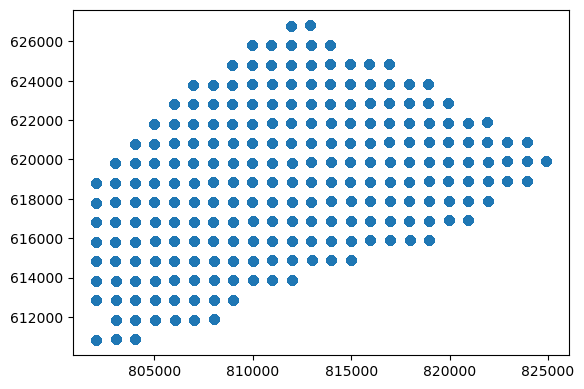

In [85]:
temp_metres.plot()

In [87]:
new1.shape

(513190, 7)

In [88]:
new1.head()

,date_left,day_of_year,geometry,latitude_left,longitude_left,value,Optical_Depth_055
0,2025-01-01,1,POINT (804782.503 620503.680),5.60724,-0.24896,24.108542,0.547
1,2025-01-01,1,POINT (809443.443 614022.593),5.54848,-0.20720,18.785000,0.505
2,2025-01-01,1,POINT (810581.644 614860.238),5.55600,-0.19690,24.209449,0.508
3,2025-01-01,1,POINT (803086.845 615102.913),5.55851,-0.26448,24.476364,0.507
4,2025-01-01,1,POINT (806298.483 615955.629),5.56608,-0.23548,23.988000,0.530


In [89]:
temp_metres.shape

(84812, 7)

In [90]:
temp_metres.head()

,CONSTITUEN,ID,date,temp_c,longitude,latitude,geometry
0,OKAIKWEI NORTH,125,2025-01-01,28.685861,-0.247037,5.600996,POINT (804998.989 619813.655)
1,OKAIKWEI NORTH,125,2025-01-01,28.692106,-0.238054,5.600996,POINT (805994.987 619818.337)
2,OKAIKWEI NORTH,125,2025-01-01,28.698352,-0.229070,5.600996,POINT (806990.993 619823.035)
3,OKAIKWEI NORTH,125,2025-01-01,28.689568,-0.247037,5.609979,POINT (804994.319 620807.792)
4,OKAIKWEI NORTH,125,2025-01-01,28.695813,-0.238054,5.609979,POINT (805990.302 620812.481)


In [91]:
temp_metres.duplicated().sum()

0

In [92]:
temp_metres.nunique()

CONSTITUEN       16
ID               12
date            364
temp_c        83720
longitude        24
latitude         17
geometry        230
dtype: int64

In [93]:
temp1 = temp_metres.dissolve(['date', 'longitude']).reset_index()

In [94]:
temp1.shape

(8736, 7)

<Axes: >

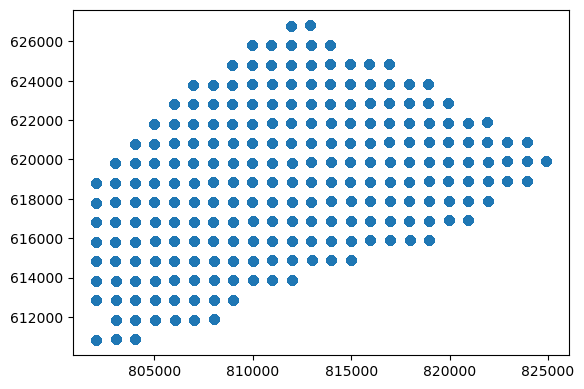

In [95]:
temp1.plot()

In [96]:
temp1.head()

,date,longitude,geometry,CONSTITUEN,ID,temp_c,latitude
0,2025-01-01,-0.273986,"MULTIPOINT (802015.655 618805.587, 802020.263 ...",ABLEKUMA CENTRAL,112,28.641175,5.538114
1,2025-01-01,-0.265003,"MULTIPOINT (803007.015 619804.337, 803011.646 ...",ABLEKUMA CENTRAL,112,28.647422,5.538114
2,2025-01-01,-0.256020,"MULTIPOINT (803998.344 620803.118, 804002.998 ...",ABLEKUMA CENTRAL,112,28.653669,5.538114
3,2025-01-01,-0.247037,"MULTIPOINT (804989.642 621801.928, 804994.319 ...",OKAIKWEI NORTH,125,28.685861,5.600996
4,2025-01-01,-0.238054,"MULTIPOINT (805980.910 622800.770, 805985.610 ...",OKAIKWEI NORTH,125,28.692106,5.600996


In [98]:
from scipy.spatial import cKDTree

In [107]:
new1.head()

,date_left,day_of_year,geometry,latitude_left,longitude_left,value,Optical_Depth_055
0,2025-01-01,1,POINT (804782.503 620503.680),5.60724,-0.24896,24.108542,0.547
1,2025-01-01,1,POINT (809443.443 614022.593),5.54848,-0.20720,18.785000,0.505
2,2025-01-01,1,POINT (810581.644 614860.238),5.55600,-0.19690,24.209449,0.508
3,2025-01-01,1,POINT (803086.845 615102.913),5.55851,-0.26448,24.476364,0.507
4,2025-01-01,1,POINT (806298.483 615955.629),5.56608,-0.23548,23.988000,0.530


In [108]:
temp1.head()

,date,longitude,geometry,CONSTITUEN,ID,temp_c,latitude
0,2025-01-01,-0.273986,"MULTIPOINT (802015.655 618805.587, 802020.263 ...",ABLEKUMA CENTRAL,112,28.641175,5.538114
1,2025-01-01,-0.265003,"MULTIPOINT (803007.015 619804.337, 803011.646 ...",ABLEKUMA CENTRAL,112,28.647422,5.538114
2,2025-01-01,-0.256020,"MULTIPOINT (803998.344 620803.118, 804002.998 ...",ABLEKUMA CENTRAL,112,28.653669,5.538114
3,2025-01-01,-0.247037,"MULTIPOINT (804989.642 621801.928, 804994.319 ...",OKAIKWEI NORTH,125,28.685861,5.600996
4,2025-01-01,-0.238054,"MULTIPOINT (805980.910 622800.770, 805985.610 ...",OKAIKWEI NORTH,125,28.692106,5.600996


In [139]:
# 1. Explode MultiPoints into simple Points
df_joined1 = df_joined1.explode(index_parts=False)
temp1 = temp1.explode(index_parts=False)

In [140]:
# 2. Keep only Point geometries (safety first)
df_joined1 = df_joined1[df_joined1.geometry.type == 'Point']
temp1 = temp1[temp1.geometry.type == 'Point']

# 3. Ensure CRS match (Crucial for distance calculation)
if df_joined1.crs != temp1.crs:
    temp1 = temp1.to_crs(df_joined1.crs)

In [141]:
# Apply the function
df_joined2 = ckdnearest(df_joined1, temp1)

In [143]:
df_joined2.head()

,date,sensor_name,value,latitude,longitude,day_of_year,is_imputed,date,Optical_Depth_055,CONSTITUEN,...,longitude,dist,geometry,date,longitude,CONSTITUEN,ID,temp_c,latitude,dist
0,2025-01-01,37 Lorry Station,16.518222,5.588920,-0.179640,1,False,2025-01-27,0.470,AYAWASO EAST,...,-0.175758,430.557856,POINT (812478.133 618512.692),2025-03-11,-0.175171,KORLE KLOTTEY,120,28.180248,5.556080,602.211048
1,2025-01-01,US Diplomatic Post: Accra,35.040000,5.579447,-0.170699,1,False,2025-01-12,0.999,DADEKOTOPON,...,-0.166719,443.425292,POINT (813474.577 617469.043),2025-02-09,-0.175171,KORLE KLOTTEY,120,27.028390,5.556080,634.945257
2,2025-01-01,Tetteh Quarshie Interchange,20.491000,5.619190,-0.176260,1,False,2025-12-351,0.263,AYAWASO WEST WUOGON,...,-0.175766,377.835895,POINT (812836.779 621864.573),2025-07-17,-0.175171,KORLE KLOTTEY,120,24.570563,5.556080,123.300337
3,2025-01-01,Tema Community Center,21.067458,5.588640,-0.268670,1,True,2025-06-157,0.210,ABLEKUMA NORTH,...,-0.266120,283.575981,POINT (802606.808 618435.092),2025-10-16,-0.265003,ABLEKUMA CENTRAL,112,25.590187,5.538114,551.916217
4,2025-01-01,Physics Department-UG-Accra/CAOA-UESD,31.646825,5.651000,-0.186000,1,False,2025-02-35,0.620,AYAWASO WEST WUOGON,...,-0.184814,157.583822,POINT (811739.853 625379.859),2025-08-25,-0.184155,KORLE KLOTTEY,120,24.554374,5.547097,477.135580


In [145]:
df_joined2.columns

Index(['date', 'sensor_name', 'value', 'latitude', 'longitude', 'day_of_year',
       'is_imputed', 'date', 'Optical_Depth_055', 'CONSTITUEN', 'latitude',
       'longitude', 'dist', 'geometry', 'date', 'longitude', 'CONSTITUEN',
       'ID', 'temp_c', 'latitude', 'dist'],
      dtype='object')

In [150]:
geog = df_joined2[['date', 'sensor_name', 'value', 'latitude', 'longitude',
                  'Optical_Depth_055','temp_c','geometry']]

In [151]:
geog.shape

(6205, 14)

In [152]:
geog.head()

,date,date,date,sensor_name,value,latitude,latitude,latitude,longitude,longitude,longitude,Optical_Depth_055,temp_c,geometry
0,2025-01-01,2025-01-27,2025-03-11,37 Lorry Station,16.518222,5.588920,5.588832,5.556080,-0.179640,-0.175758,-0.175171,0.470,28.180248,POINT (812478.133 618512.692)
1,2025-01-01,2025-01-12,2025-02-09,US Diplomatic Post: Accra,35.040000,5.579447,5.579839,5.556080,-0.170699,-0.166719,-0.175171,0.999,27.028390,POINT (813474.577 617469.043)
2,2025-01-01,2025-12-351,2025-07-17,Tetteh Quarshie Interchange,20.491000,5.619190,5.615812,5.556080,-0.176260,-0.175766,-0.175171,0.263,24.570563,POINT (812836.779 621864.573)
3,2025-01-01,2025-06-157,2025-10-16,Tema Community Center,21.067458,5.588640,5.588832,5.538114,-0.268670,-0.266120,-0.265003,0.210,25.590187,POINT (802606.808 618435.092)
4,2025-01-01,2025-02-35,2025-08-25,Physics Department-UG-Accra/CAOA-UESD,31.646825,5.651000,5.651785,5.547097,-0.186000,-0.184814,-0.184155,0.620,24.554374,POINT (811739.853 625379.859)


In [153]:
# 1. Remove duplicate column names
geog1 = geog.loc[:, ~geog.columns.duplicated()].copy()

In [154]:
geog1.head()

,date,sensor_name,value,latitude,longitude,Optical_Depth_055,temp_c,geometry
0,2025-01-01,37 Lorry Station,16.518222,5.588920,-0.179640,0.470,28.180248,POINT (812478.133 618512.692)
1,2025-01-01,US Diplomatic Post: Accra,35.040000,5.579447,-0.170699,0.999,27.028390,POINT (813474.577 617469.043)
2,2025-01-01,Tetteh Quarshie Interchange,20.491000,5.619190,-0.176260,0.263,24.570563,POINT (812836.779 621864.573)
3,2025-01-01,Tema Community Center,21.067458,5.588640,-0.268670,0.210,25.590187,POINT (802606.808 618435.092)
4,2025-01-01,Physics Department-UG-Accra/CAOA-UESD,31.646825,5.651000,-0.186000,0.620,24.554374,POINT (811739.853 625379.859)


In [155]:
pbl1 = pbl[['ID', 'pbl_m','geometry']]

In [156]:
# 1. Explode MultiPoints into simple Points
geog1 = geog1.explode(index_parts=False)
pbl1 = pbl1.explode(index_parts=False)

In [157]:
# 2. Keep only Point geometries (safety first)
geog1 = geog1[geog1.geometry.type == 'Point']
pbl1 = pbl1[pbl1.geometry.type == 'Point']

# 3. Ensure CRS match (Crucial for distance calculation)
if pbl1.crs != pbl1.crs:
    pbl1 = pbl1.to_crs(geog1.crs)

In [158]:
geo_final = ckdnearest(geog1, pbl1)

In [159]:
geo_final.head()

,date,sensor_name,value,latitude,longitude,Optical_Depth_055,temp_c,geometry,ID,pbl_m,dist
0,2025-01-01,37 Lorry Station,16.518222,5.588920,-0.179640,0.470,28.180248,POINT (812478.133 618512.692),125,601.40260,602.211048
1,2025-01-01,US Diplomatic Post: Accra,35.040000,5.579447,-0.170699,0.999,27.028390,POINT (813474.577 617469.043),125,541.75520,634.945257
2,2025-01-01,Tetteh Quarshie Interchange,20.491000,5.619190,-0.176260,0.263,24.570563,POINT (812836.779 621864.573),125,624.07060,123.300337
3,2025-01-01,Tema Community Center,21.067458,5.588640,-0.268670,0.210,25.590187,POINT (802606.808 618435.092),125,457.23734,551.916217
4,2025-01-01,Physics Department-UG-Accra/CAOA-UESD,31.646825,5.651000,-0.186000,0.620,24.554374,POINT (811739.853 625379.859),125,556.13416,477.135580


In [160]:
geo_final.nunique()

date                  365
sensor_name            17
value                1100
latitude               17
longitude              17
Optical_Depth_055      16
temp_c                 15
geometry               17
ID                      1
pbl_m                  15
dist                   17
dtype: int64

<Axes: >

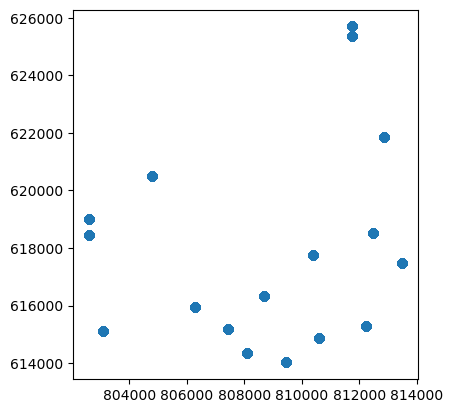

In [161]:
geo_final.plot()

In [163]:
rh = gpd.read_file("Garh_study_area.geojson")

<Axes: >

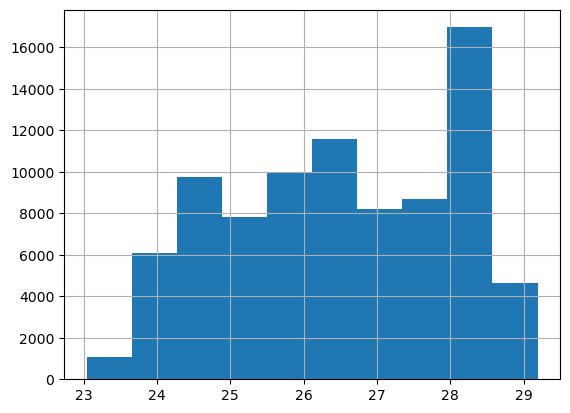

In [182]:
rh['temp_c'].hist()

In [180]:
rh.shape

(84812, 8)

In [211]:
geo_final1 = geo_final.drop('temp_c', axis=1)

In [200]:
rh.columns

Index(['CONSTITUEN', 'ID', 'date', 'rh_percent', 'temp_c', 'longitude',
       'latitude', 'geometry'],
      dtype='object')

In [212]:
rh1 = rh[['date', 'rh_percent', 'temp_c','longitude',
       'latitude', 'geometry']]

In [213]:
# 3. Ensure CRS match (Crucial for distance calculation)
if rh1.crs != rh1.crs:
    rh1 = rh1.to_crs(geo_final1.crs)

In [214]:
rh1 = rh1.to_crs(epsg=32630)

In [215]:
geog_new = geo_final1.sjoin_nearest(rh1, how='inner', max_distance=None, 
                                  lsuffix='left', rsuffix='right', 
                                  distance_col=None)

In [207]:
geog_new.tail()

,date_left,sensor_name,value,latitude_left,longitude_left,Optical_Depth_055,temp_c,geometry,ID,pbl_m,dist,index_right,date_right,rh_percent,longitude_right,latitude_right
6127,2025-12-27,Lapaz Intersection,12.812874,5.60724,-0.24896,0.227,25.604616,POINT (804782.503 620503.680),125,399.31696,370.607914,41011,2025-06-177,84.566578,-0.247037,5.609979
6145,2025-12-28,Lapaz Intersection,12.812874,5.60724,-0.24896,0.227,25.604616,POINT (804782.503 620503.680),125,399.31696,370.607914,41011,2025-06-177,84.566578,-0.247037,5.609979
6170,2025-12-29,Lapaz Intersection,12.812874,5.60724,-0.24896,0.227,25.604616,POINT (804782.503 620503.680),125,399.31696,370.607914,41011,2025-06-177,84.566578,-0.247037,5.609979
6178,2025-12-30,Lapaz Intersection,12.812874,5.60724,-0.24896,0.227,25.604616,POINT (804782.503 620503.680),125,399.31696,370.607914,41011,2025-06-177,84.566578,-0.247037,5.609979
6194,2025-12-31,Lapaz Intersection,12.812874,5.60724,-0.24896,0.227,25.604616,POINT (804782.503 620503.680),125,399.31696,370.607914,41011,2025-06-177,84.566578,-0.247037,5.609979


In [216]:
geog_new.columns

Index(['date_left', 'sensor_name', 'value', 'latitude_left', 'longitude_left',
       'Optical_Depth_055', 'geometry', 'ID', 'pbl_m', 'dist', 'index_right',
       'date_right', 'rh_percent', 'temp_c', 'longitude_right',
       'latitude_right'],
      dtype='object')

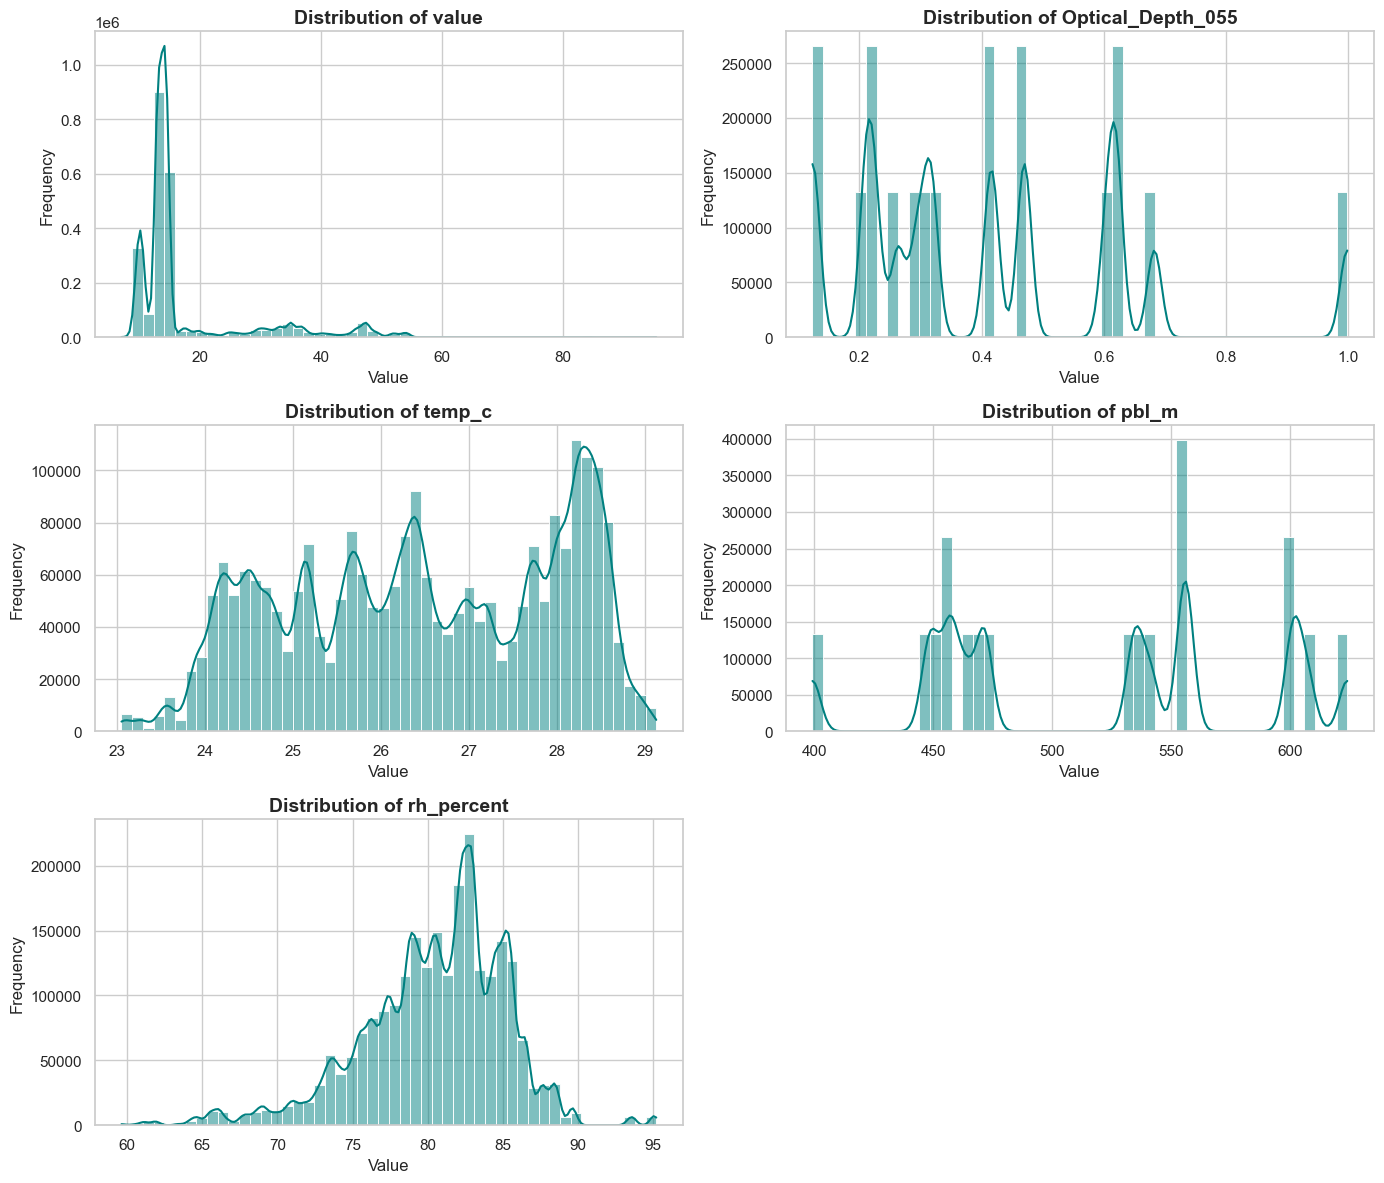

In [217]:
# Define your list of variables
vars_to_plot = ['value', 'Optical_Depth_055', 'temp_c', 'pbl_m', 'rh_percent']

# Set the style for a scientific publication
sns.set_theme(style="whitegrid")

# Create a figure with subplots (3 rows, 2 columns)
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(14, 12))
axes = axes.flatten() # Flatten to loop easily

for i, var in enumerate(vars_to_plot):
    # Filter out NaNs just for the plot to avoid warnings
    plot_data = geog_new[var].dropna()
    
    sns.histplot(plot_data, bins=50, kde=True, ax=axes[i], color='teal')
    
    # Labeling
    axes[i].set_title(f'Distribution of {var}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')

# Remove the empty 6th subplot (since we only have 5 variables)
fig.delaxes(axes[5])

plt.tight_layout()
plt.show()